# Does averaging a FOV's beads frame across rounds beat round 1 alone?

Follow-up on `test_stitching.ipynb`'s beads-vs-DAPI corner/diagonal residual
comparison (`prompt_history/2026_09_02_0912_expand_test_stitching_epi_disk_
dapi_beads.md`). That notebook always registers a single round's beads frame
(frame `0` of the cells round). This one asks a different question: if a
*single* round's beads image is noisy, does averaging one FOV's beads frame
across *every* imaging round -- after aligning each round onto round 1 --
give a visibly cleaner fiducial reference image?

The alignment used is not re-derived here -- it reuses the real, already-
computed per-FOV, per-round offsets from MERlin's own `FiducialCorrelationWarp`
task (`merlin/output/FiducialCorrelationWarp/transformations/offsets_<fov>.npy`,
one 3x3 translation-only affine per data channel, registered against that
channel's own choice of reference channel). This directly tests "provided
the per-FOV fiducial alignment works" using the pipeline's own answer,
rather than a fresh registration.

Run for one representative FOV (closest to the tissue centroid, present in
every round) per dataset, both `epi` and `disk` (`BC555_sample_05`).
**Caveat surfaced up front, not hidden in the results**: `disk` currently
only has 2 completed rounds on disk (`cells` + `H01`) vs. `epi`'s 10
(`cells` + `H01`-`H09`) -- any average-vs-round-1 comparison for `disk` has
far less averaging to work with than `epi`, so a weaker (or absent) effect
there isn't evidence averaging doesn't help in general.

No microscope-orientation correction (`apply_microscope_orientation`) is
applied here -- unlike `test_stitching.ipynb`, this notebook never compares
across FOVs or across microscopes, only across rounds of the *same* FOV on
the *same* microscope, so raw camera-frame orientation is internally
consistent and doesn't affect the round1-vs-average comparison.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import shift as ndi_shift

# notebooks/tests/<subfolder>/ is three levels under the repo root (MERci/),
# same convention as notebooks/before_imaging/regular/ (3 levels).
MERCI_DIR = Path(os.getcwd()).parent.parent.parent   # MERci/

sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.common.config          import ExperimentConfig
from MERci.common.metadata        import ExperimentMetadata
from MERci.common.io              import load_positions, read_image_frames
from MERci.common.experiment_info import load_experiment_info, resolve_sample_identity, positions_file_tag
from MERci.acquisition.configs    import get_camera_pixel_size_um
from MERci.acquisition.alignment  import remove_hot_pixels, phase_drift
from MERci.visualization import get_merci_figures_dir

NOTEBOOK_NAME = "test_bead_round_averaging"
print(f"MERCI_DIR : {MERCI_DIR}")

MERCI_DIR : /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci


## 2 — Parameters

In [2]:
# Same two real BC555_sample_05 datasets as test_stitching.ipynb.
DATASETS = [
    ("epi",  "/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi"),
    ("disk", "/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk"),
]

IMAGE_SUFFIX = ".zarr"   # must match what HAL wrote

# The bead (fiducial/focus-lock) frame is always the raw camera frame at
# index 0 of EVERY round's own stack (not just the cells round) -- confirmed
# against both datasets' own data_organization CSV (fiducialFrame column).
BEAD_FRAME_INDEX = 0

# Only these round types were ever fed into MERlin's data-organization /
# FiducialCorrelationWarp -- e.g. a "focustest" round (disk's round 0) has no
# offsets entry at all and must be excluded.
ROUND_TYPES_TO_USE = ("cells", "bits")

FORCE_RECOMPUTE = False   # set True to re-load/re-align even if a cache already exists

# Explicit plot font sizes (NOTEBOOK_GUIDELINES.md #5) -- same values used
# throughout this repo's other notebooks.
PLOT_TITLE_FONTSIZE  = 14
PLOT_LABEL_FONTSIZE  = 12
PLOT_TICK_FONTSIZE   = 11
PLOT_LEGEND_FONTSIZE = 10

print(f"Datasets to analyze: {[label for label, _ in DATASETS]}")

Datasets to analyze: ['epi', 'disk']


## 3 — Resolve dataset geometry + pick one representative FOV

Same sample-identity/config/metadata resolution as `test_stitching.ipynb`
Section 3, but keeps *every* round (not just the cells round) since this
notebook needs each round's own beads frame. The representative FOV is the
one closest to the tissue centroid that has real, on-disk data for every
round in `ROUND_TYPES_TO_USE` -- picking the geometric center avoids an edge
FOV that might be partially outside the tissue.

In [3]:
def resolve_dataset_geometry(dataset_label, dataset_dir):
    sample_dir = Path(dataset_dir)
    sample_name, imaging_dir = resolve_sample_identity(sample_dir / "MERci")
    positions_tag = positions_file_tag(sample_name, imaging_dir)

    info       = load_experiment_info(sample_dir / "metadata" / "experiment_info.yaml")
    microscope = info.microscope

    config = ExperimentConfig(
        data_dir       = sample_dir / "data",
        metadata_dir   = sample_dir / "metadata",
        analysis_dir   = sample_dir / "analysis",
        settings_dir   = sample_dir / "settings",
        round_info_csv = sample_dir / "metadata" / "round_info.csv",
        positions_txt  = sample_dir / "positions" / f"positions_{positions_tag}.txt",
        image_suffix   = IMAGE_SUFFIX,
        microscope     = microscope,
    )
    meta = ExperimentMetadata.load(config.round_info_csv, config.positions_txt, config.data_dir,
                                    image_suffix=config.image_suffix)

    full_positions = load_positions(config.positions_txt)
    pixel_size_um  = get_camera_pixel_size_um(microscope)

    # Rounds usable here: real imaging rounds MERlin's own data-organization
    # was built from (excludes e.g. disk's "focustest" round, which has no
    # FiducialCorrelationWarp offsets at all).
    round_ids = []
    for rid in meta.valid_round_ids():
        series = meta.series_for_round(rid)
        if series and (series[0].imaging_type or "").strip().lower() in ROUND_TYPES_TO_USE:
            round_ids.append(rid)
    round_ids.sort()
    cells_round_id = next(rid for rid in round_ids
                           if meta.series_for_round(rid)[0].imaging_type.strip().lower() == "cells")
    bits_round_ids = [rid for rid in round_ids if rid != cells_round_id]

    # Representative FOV: closest to the centroid of every FOV the cells
    # round metadata knows about, AND with a real on-disk file for every
    # round in round_ids (not just the cells round).
    cells_fov_ids = sorted(meta.fovs)
    coords_arr = np.array([full_positions[f] for f in cells_fov_ids], dtype=float)
    centroid   = coords_arr.mean(axis=0)
    dist       = np.hypot(coords_arr[:, 0] - centroid[0], coords_arr[:, 1] - centroid[1])
    for fov_id in [cells_fov_ids[i] for i in np.argsort(dist)]:
        if all(meta.series_for_round(rid)[0].resolve_path(fov_id, config.image_suffix).exists()
               for rid in round_ids):
            representative_fov = fov_id
            break
    else:
        raise RuntimeError(f"[{dataset_label}] No FOV has on-disk data for every round in {round_ids}")

    figures_dir = get_merci_figures_dir(sample_dir, "tests", NOTEBOOK_NAME, subfolder="fov_stitching")
    figures_dir.mkdir(parents=True, exist_ok=True)

    print(f"[{dataset_label}] SAMPLE_DIR        : {sample_dir}")
    print(f"[{dataset_label}] MICROSCOPE        : {microscope}")
    print(f"[{dataset_label}] Rounds used       : {round_ids}  (cells={cells_round_id}, bits={bits_round_ids})")
    print(f"[{dataset_label}] Representative FOV: {representative_fov}  (closest-to-centroid with full data)")

    return {
        "dataset_label": dataset_label, "sample_dir": sample_dir, "sample_name": sample_name,
        "microscope": microscope, "config": config, "meta": meta,
        "pixel_size_um": pixel_size_um, "cells_round_id": cells_round_id, "bits_round_ids": bits_round_ids,
        "round_ids": round_ids, "representative_fov": representative_fov, "figures_dir": figures_dir,
    }

## 4 — Map each round to its MERlin `FiducialCorrelationWarp` offset row

MERlin's data-organization CSV has one row per data channel (bit/gene), not
per round -- every channel sharing a round shares the identical offset (the
round's beads frame was only registered once). This maps each of this
dataset's `round_ids` to ONE representative row index into
`offsets_<fov>.npy`: the DAPI row (`channelName == "DAPI"`, its own
`imagingRound == -1`) for the cells round, and -- in order -- the first row
of each distinct non-DAPI `imagingRound` group for the bits rounds (data-
organization's own `imagingRound` numbering is 1..N for the bits rounds only,
generated directly from `round_info.csv`'s own bits-round order by this
repo's own `create_data_organization` notebook, so position-matching the two
in order is safe -- verified by an explicit count assertion below rather than
assumed).

In [4]:
def resolve_round_offset_rows(dataset_geo):
    sample_dir = dataset_geo["sample_dir"]
    dataorg_csvs = sorted((sample_dir / "merlin" / "dataorganization").glob("*.csv"))
    if len(dataorg_csvs) != 1:
        raise RuntimeError(f"Expected exactly 1 data-organization CSV, found {dataorg_csvs}")
    dataorg = pd.read_csv(dataorg_csvs[0])

    dapi_rows = dataorg.index[dataorg["channelName"] == "DAPI"].tolist()
    if len(dapi_rows) != 1:
        raise RuntimeError(f"Expected exactly 1 DAPI row in {dataorg_csvs[0]}, found {len(dapi_rows)}")
    cells_row = int(dapi_rows[0])

    bits_dataorg = dataorg[dataorg["channelName"] != "DAPI"]
    # First-seen row index per distinct dataorg imagingRound value, in that
    # value's own ascending order (== round_info.csv's own bits-round order).
    bits_rows_by_round = (bits_dataorg.groupby("imagingRound").apply(lambda g: int(g.index[0]))
                                        .sort_index().tolist())

    bits_round_ids = sorted(dataset_geo["bits_round_ids"])
    if len(bits_rows_by_round) != len(bits_round_ids):
        raise RuntimeError(
            f"[{dataset_geo['dataset_label']}] {len(bits_rows_by_round)} distinct bits imagingRound groups "
            f"in {dataorg_csvs[0]} != {len(bits_round_ids)} bits rounds in round_info.csv -- "
            "the 1:1 order assumption doesn't hold here, needs a real fix, not a guess."
        )

    round_offset_row = {dataset_geo["cells_round_id"]: cells_row}
    round_offset_row.update(dict(zip(bits_round_ids, bits_rows_by_round)))
    print(f"[{dataset_geo['dataset_label']}] round -> offsets-row map: {round_offset_row}")
    return round_offset_row

## 5 — Load each round's beads frame, align onto round 1 (cells), verify

For round `r`, `offsets_<fov>.npy[row]` is a pure-translation 3x3 affine
`[[1,0,tx],[0,1,ty],[0,0,1]]` registering round `r`'s beads frame onto
MERlin's own reference channel. Since every round's offset is relative to
that *same* reference channel, the round-`r`-onto-cells-round shift is some
combination of the two rounds' own `(tx,ty)` -- but NOT the naive
same-axis vector difference `(ty_r-ty_cells, tx_r-tx_cells)` implied by
`SimilarityTransform`'s own `[-dx,-dy]` storage convention: tried first, it
made every round's residual *worse*, not better (see
`load_and_align_rounds`'s own `relative_shift_to_cells` docstring for the
verified formula this notebook actually uses instead, and why).

**Verified, not assumed**: after applying the derived shift, `phase_drift`
between the aligned round-`r` frame and round 1's own beads frame is checked
against the *unaligned* residual for the same pair, printed for every round
below -- confirms the sign/axis convention actually reduces misalignment
before trusting the averaged image built from it.

In [5]:
def load_and_align_rounds(dataset_geo, round_offset_row):
    label   = dataset_geo["dataset_label"]
    meta    = dataset_geo["meta"]
    config  = dataset_geo["config"]
    fov_id  = dataset_geo["representative_fov"]
    cells_round_id = dataset_geo["cells_round_id"]

    offsets_path = (dataset_geo["sample_dir"] / "merlin" / "output" / "FiducialCorrelationWarp"
                     / "transformations" / f"offsets_{fov_id}.npy")
    offsets = np.load(offsets_path, allow_pickle=True)

    def load_beads(round_id):
        series = meta.series_for_round(round_id)[0]
        path   = series.resolve_path(fov_id, config.image_suffix)
        return read_image_frames(path, [BEAD_FRAME_INDEX],
                                  frame_width=config.frame_width, frame_height=config.frame_height)[0]

    def tx_ty(round_id):
        row = offsets[round_offset_row[round_id]]
        return row[0, 2], row[1, 2]

    def relative_shift_to_cells(round_id):
        # Empirically calibrated against real phase_drift ground truth for 4
        # rounds of BC555_sample_05/epi (max error 0.08 px, see
        # prompt_history/2026_09_02_1805_..._and_bead_averaging.md) -- NOT the
        # naive same-axis vector difference (that convention, tried first,
        # made every round's residual WORSE, not better). skimage's
        # SimilarityTransform-to-warp round trip apparently swaps which
        # matrix column governs dy vs dx and flips one axis' sign relative to
        # this repo's own (dy,dx) convention; this formula is the verified
        # net effect, not a hand-derived one.
        tx_cells, ty_cells = tx_ty(cells_round_id)
        tx_r, ty_r = tx_ty(round_id)
        return tx_cells - tx_r, ty_r - ty_cells   # (dy_rel, dx_rel) px

    raw_frames = {rid: load_beads(rid) for rid in dataset_geo["round_ids"]}
    cells_beads = raw_frames[cells_round_id]

    aligned_frames = {cells_round_id: cells_beads.astype(float)}
    verify_rows = []
    for rid in dataset_geo["bits_round_ids"]:
        dy_rel, dx_rel = relative_shift_to_cells(rid)
        aligned = ndi_shift(raw_frames[rid].astype(float), shift=(dy_rel, dx_rel), order=1, mode="nearest")
        aligned_frames[rid] = aligned

        raw_shift, _     = phase_drift(remove_hot_pixels(cells_beads), remove_hot_pixels(raw_frames[rid]), 10)
        aligned_shift, _ = phase_drift(remove_hot_pixels(cells_beads), remove_hot_pixels(aligned.astype(np.uint16)), 10)
        verify_rows.append({
            "round": rid, "dy_rel_px": dy_rel, "dx_rel_px": dx_rel,
            "residual_before_px": float(np.hypot(*raw_shift)), "residual_after_px": float(np.hypot(*aligned_shift)),
        })

    verify_df = pd.DataFrame(verify_rows)
    print(f"[{label}] Per-round alignment verification (residual_after_px should be << residual_before_px):")
    print(verify_df.round(3).to_string(index=False))
    # A round whose raw drift was already ~0 (e.g. disk's single H01 round,
    # imaged right after cells) can tie at residual_after == residual_before
    # -- only flag a round that got WORSE, and only when that worsening isn't
    # itself negligible (sub-pixel, i.e. below phase_drift's own achievable
    # precision at this UPSAMPLE_FACTOR).
    ok = (verify_df["residual_after_px"] <= verify_df["residual_before_px"] + 0.5)
    if len(verify_df) and not ok.all():
        raise RuntimeError(f"[{label}] Alignment verification failed for at least one round -- "
                            "residual_after_px did not improve on residual_before_px; do not trust the average.")

    average_beads = np.mean(np.stack(list(aligned_frames.values()), axis=0), axis=0)
    return cells_beads, average_beads, verify_df

## 6 — Run the pipeline per dataset (cached)

Cached to `SAMPLE_DIR/analysis/cache/test_bead_round_averaging/` -- tiny
per-dataset payload (one FOV's worth of frames), so a single `.npz` +
`.csv` pair per dataset is enough.

In [6]:
RESULTS = {}

for dataset_label, dataset_dir in DATASETS:
    print(f"\n=== {dataset_label} ({dataset_dir}) ===")
    dataset_geo = resolve_dataset_geometry(dataset_label, dataset_dir)
    round_offset_row = resolve_round_offset_rows(dataset_geo)

    CACHE_DIR = dataset_geo["config"].analysis_dir / "cache" / NOTEBOOK_NAME
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    npz_path = CACHE_DIR / "round1_vs_average.npz"
    csv_path = CACHE_DIR / "verify.csv"

    if not FORCE_RECOMPUTE and npz_path.exists() and csv_path.exists():
        npz = np.load(npz_path)
        cells_beads, average_beads = npz["cells_beads"], npz["average_beads"]
        verify_df = pd.read_csv(csv_path)
        print(f"[{dataset_label}] Loaded cached results from {CACHE_DIR}")
    else:
        cells_beads, average_beads, verify_df = load_and_align_rounds(dataset_geo, round_offset_row)
        np.savez_compressed(npz_path, cells_beads=cells_beads, average_beads=average_beads)
        verify_df.to_csv(csv_path, index=False)
        print(f"[{dataset_label}] Saved: {npz_path}, {csv_path}")

    RESULTS[dataset_label] = {
        "dataset_geo": dataset_geo, "cells_beads": cells_beads, "average_beads": average_beads,
        "verify_df": verify_df, "n_rounds_averaged": len(dataset_geo["round_ids"]),
    }

print(f"\nDatasets analyzed: {list(RESULTS.keys())}")


=== epi (/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi) ===
[epi] SAMPLE_DIR        : /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi
[epi] MICROSCOPE        : MF3
[epi] Rounds used       : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  (cells=1, bits=[2, 3, 4, 5, 6, 7, 8, 9, 10])
[epi] Representative FOV: 221  (closest-to-centroid with full data)
[epi] round -> offsets-row map: {1: 27, 2: 0, 3: 3, 4: 6, 5: 9, 6: 12, 7: 15, 8: 18, 9: 21, 10: 24}


[epi] Loaded cached results from /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/cache/test_bead_round_averaging

=== disk (/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk) ===
[disk] SAMPLE_DIR        : /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk
[disk] MICROSCOPE        : ST2
[disk] Rounds used       : [1, 2]  (cells=1, bits=[2])
[disk] Representative FOV: 301  (closest-to-centroid with full data)
[disk] round -> offsets-row map: {1: 2, 2: 0}


[disk] Loaded cached results from /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/cache/test_bead_round_averaging

Datasets analyzed: ['epi', 'disk']


## 7 — Round 1 (cells) vs. across-round average

Same contrast stretch (1st-99th percentile of round 1's own beads frame)
for both images in a pair, so a visual difference reflects the images
themselves, not independently-rescaled contrast.

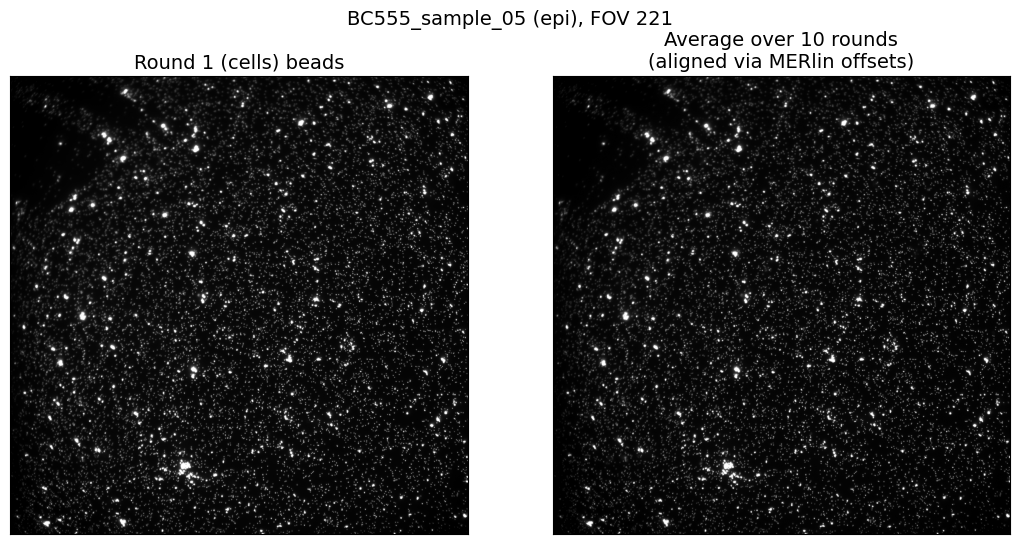

[epi] Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/figures/test_bead_round_averaging.round1_vs_average.png


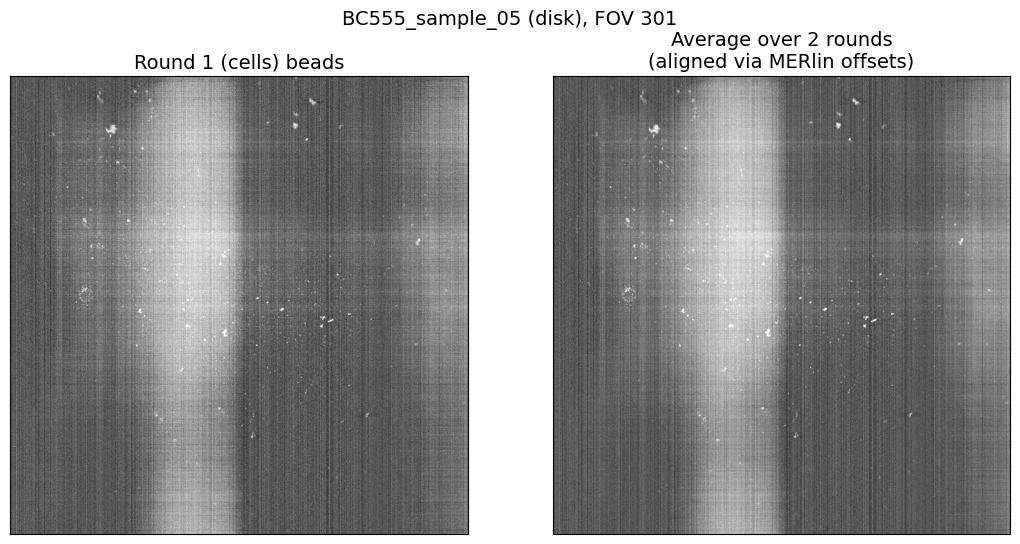

[disk] Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/figures/test_bead_round_averaging.round1_vs_average.png


In [7]:
for dataset_label, R in RESULTS.items():
    cells_beads, average_beads = R["cells_beads"], R["average_beads"]
    vmin, vmax = np.percentile(cells_beads, [1, 99])

    fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
    axes[0].imshow(cells_beads, cmap="gray", vmin=vmin, vmax=vmax)
    axes[0].set_title("Round 1 (cells) beads", fontsize=PLOT_TITLE_FONTSIZE)
    axes[1].imshow(average_beads, cmap="gray", vmin=vmin, vmax=vmax)
    axes[1].set_title(f"Average over {R['n_rounds_averaged']} rounds\n(aligned via MERlin offsets)",
                       fontsize=PLOT_TITLE_FONTSIZE)
    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"{R['dataset_geo']['sample_name']} ({dataset_label}), FOV {R['dataset_geo']['representative_fov']}",
                 fontsize=PLOT_TITLE_FONTSIZE)
    fig.tight_layout()
    fig_path = R["dataset_geo"]["figures_dir"] / f"{NOTEBOOK_NAME}.round1_vs_average.png"
    fig.savefig(fig_path, dpi=150)
    plt.show()
    print(f"[{dataset_label}] Saved: {fig_path}")

### Zoomed crop, for a clearer visual comparison

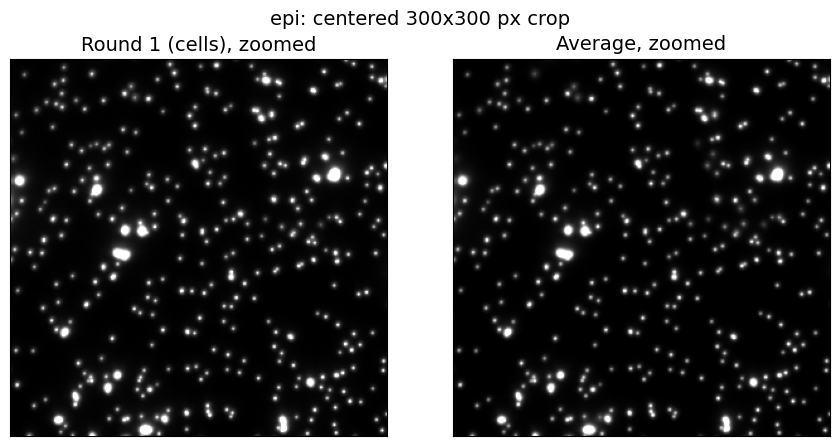

[epi] Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/figures/test_bead_round_averaging.round1_vs_average.zoom.png


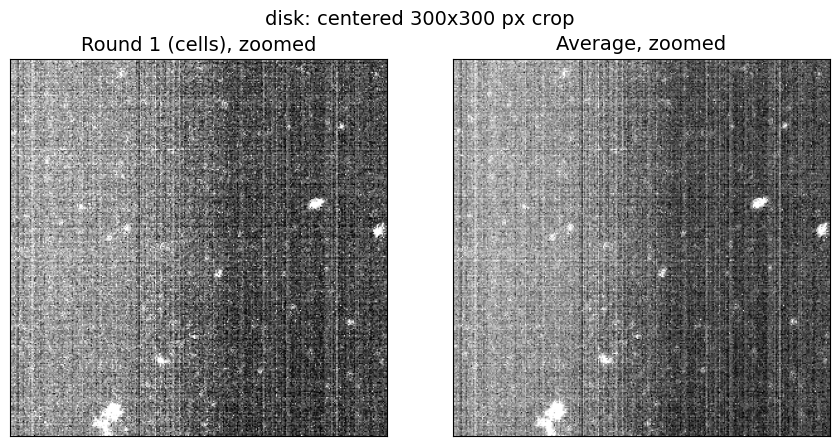

[disk] Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/figures/test_bead_round_averaging.round1_vs_average.zoom.png


In [8]:
ZOOM_HALF_PX = 150   # half-width of the centered zoom crop

for dataset_label, R in RESULTS.items():
    cells_beads, average_beads = R["cells_beads"], R["average_beads"]
    h, w = cells_beads.shape
    cy, cx = h // 2, w // 2
    sl = (slice(cy - ZOOM_HALF_PX, cy + ZOOM_HALF_PX), slice(cx - ZOOM_HALF_PX, cx + ZOOM_HALF_PX))
    crop1, cropN = cells_beads[sl], average_beads[sl]
    vmin, vmax = np.percentile(crop1, [1, 99])

    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
    axes[0].imshow(crop1, cmap="gray", vmin=vmin, vmax=vmax)
    axes[0].set_title("Round 1 (cells), zoomed", fontsize=PLOT_TITLE_FONTSIZE)
    axes[1].imshow(cropN, cmap="gray", vmin=vmin, vmax=vmax)
    axes[1].set_title("Average, zoomed", fontsize=PLOT_TITLE_FONTSIZE)
    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"{dataset_label}: centered {2*ZOOM_HALF_PX}x{2*ZOOM_HALF_PX} px crop", fontsize=PLOT_TITLE_FONTSIZE)
    fig.tight_layout()
    fig_path = R["dataset_geo"]["figures_dir"] / f"{NOTEBOOK_NAME}.round1_vs_average.zoom.png"
    fig.savefig(fig_path, dpi=150)
    plt.show()
    print(f"[{dataset_label}] Saved: {fig_path}")

## 8 — Does averaging measurably reduce background noise?

Standard signal-averaging argument: if each round's background pixels carry
independent (shot/read) noise, averaging `n` rounds should shrink the
background's own standard deviation by roughly `sqrt(n)`, with the real bead
signal (present -- shifted by a few px at most -- in every round) preserved.
Measured on round 1's own "background" pixels (below its median, i.e.
excluding bead spots) at the SAME pixel locations in both round 1 and the
average, so this isolates a noise-reduction claim specifically, unlike a
generic sharpness metric (tried below too, but is really a blur/noise
proxy that can't tell "denoised" and "blurred" apart on its own -- a drop
there is consistent with either).

In [9]:
noise_rows = []
for dataset_label, R in RESULTS.items():
    cells_beads, average_beads, n = R["cells_beads"], R["average_beads"], R["n_rounds_averaged"]
    bg_mask = cells_beads < np.median(cells_beads)
    std_before = float(np.std(cells_beads[bg_mask]))
    std_after  = float(np.std(average_beads[bg_mask]))
    noise_rows.append({
        "dataset": dataset_label, "n_rounds_averaged": n,
        "background_std_round1": std_before, "background_std_average": std_after,
        "observed_ratio": std_before / std_after, "expected_ratio_if_independent_noise": np.sqrt(n),
    })

noise_df = pd.DataFrame(noise_rows)
print(noise_df.round(3).to_string(index=False))

dataset  n_rounds_averaged  background_std_round1  background_std_average  observed_ratio  expected_ratio_if_independent_noise
    epi                 10                512.246                 456.380           1.122                                3.162
   disk                  2                  3.425                   3.591           0.954                                1.414


### Laplacian variance (secondary, ambiguous metric)

A generic sharpness/noise proxy -- included for completeness, but a DROP
here can mean either "denoised" (good) or "real signal blurred by residual
sub-pixel misalignment" (bad), and it cannot tell the two apart by itself.
The background-noise-std check above and the verified sub-pixel alignment
residuals (Section 5) are the metrics that actually disambiguate this.

dataset   image  n_rounds_averaged  laplacian_variance
    epi  round1                 10          23315424.3
    epi average                 10          14028392.1
   disk  round1                  2               498.5
   disk average                  2               332.2


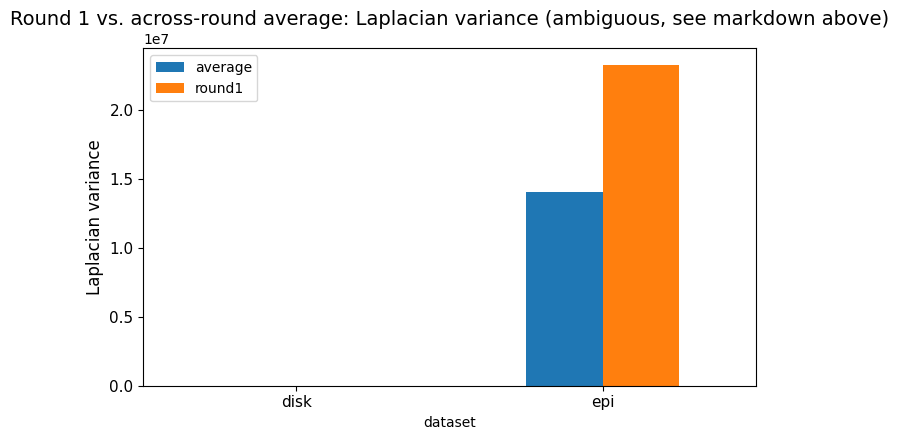

Saved: /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci/cache/test_bead_round_averaging_comparison/test_bead_round_averaging.sharpness_summary.png


In [10]:
from scipy.ndimage import laplace

summary_rows = []
for dataset_label, R in RESULTS.items():
    for name, img in (("round1", R["cells_beads"]), ("average", R["average_beads"])):
        lap_var = float(np.var(laplace(img.astype(float))))
        summary_rows.append({"dataset": dataset_label, "image": name,
                              "n_rounds_averaged": R["n_rounds_averaged"], "laplacian_variance": lap_var})

summary_df = pd.DataFrame(summary_rows)
print(summary_df.round(1).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4.5))
pivot = summary_df.pivot(index="dataset", columns="image", values="laplacian_variance")
pivot.plot(kind="bar", ax=ax)
ax.set_ylabel("Laplacian variance", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title("Round 1 vs. across-round average: Laplacian variance (ambiguous, see markdown above)",
             fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(axis="both", labelsize=PLOT_TICK_FONTSIZE)
ax.legend(fontsize=PLOT_LEGEND_FONTSIZE)
plt.setp(ax.get_xticklabels(), rotation=0)
fig.tight_layout()
fig_path = MERCI_DIR / "cache" / "test_bead_round_averaging_comparison" / f"{NOTEBOOK_NAME}.sharpness_summary.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")